In [2]:
import polars as pl
import altair as alt
import pyarrow as pa
import matplotlib.pyplot as plt
import polars as pl
import seaborn as sns
import geopandas as gpd
from matplotlib.colors import LinearSegmentedColormap

alt.data_transformers.enable("vegafusion")
plt.style.use('seaborn-v0_8-whitegrid')

df = pl.read_parquet("../data/processed/aemet_clean.parquet")
df_pd = df.to_pandas()

In [4]:
prov_map = {
    'Illes Balears': 'ILLES BALEARS',
    'Asturias': 'ASTURIAS',
    'A Coruña': 'A CORUÑA',
    'Girona': 'GIRONA',
    'Las Palmas': 'LAS PALMAS',
    'Pontevedra': 'PONTEVEDRA',
    'Santa Cruz De Tenerife': 'SANTA CRUZ DE TENERIFE',
    'Cantabria': 'CANTABRIA',
    'Málaga': 'MALAGA',
    'Almería': 'ALMERIA',
    'Murcia': 'MURCIA',
    'Albacete': 'ALBACETE',
    'Ávila': 'AVILA',
    'Araba/Álava': 'ARABA/ALAVA',
    'Badajoz': 'BADAJOZ',
    'Alacant/Alicante': 'ALICANTE',
    'Ourense': 'OURENSE',
    'Barcelona': 'BARCELONA',
    'Burgos': 'BURGOS',
    'Cáceres': 'CACERES',
    'Cádiz': 'CADIZ',
    'Castelló/Castellón': 'CASTELLON',
    'Ciudad Real': 'CIUDAD REAL',
    'Jaén': 'JAEN',
    'Córdoba': 'CORDOBA',
    'Cuenca': 'CUENCA',
    'Granada': 'GRANADA',
    'Guadalajara': 'GUADALAJARA',
    'Gipuzkoa/Guipúzcoa': 'GIPUZKOA',
    'Huelva': 'HUELVA',
    'Huesca': 'HUESCA',
    'León': 'LEON',
    'Lleida': 'LLEIDA',
    'La Rioja': 'LA RIOJA',
    'Soria': 'SORIA',
    'Navarra': 'NAVARRA',
    'Ceuta': 'CEUTA',
    'Lugo': 'LUGO',
    'Madrid': 'MADRID',
    'Palencia': 'PALENCIA',
    'Salamanca': 'SALAMANCA',
    'Segovia': 'SEGOVIA',
    'Sevilla': 'SEVILLA',
    'Toledo': 'TOLEDO',
    'Tarragona': 'TARRAGONA',
    'Teruel': 'TERUEL',
    'València/Valencia': 'VALENCIA',
    'Valladolid': 'VALLADOLID',
    'Bizkaia/Vizcaya': 'BIZKAIA',
    'Zamora': 'ZAMORA',
    'Zaragoza': 'ZARAGOZA',
    'Melilla': 'MELILLA',
}

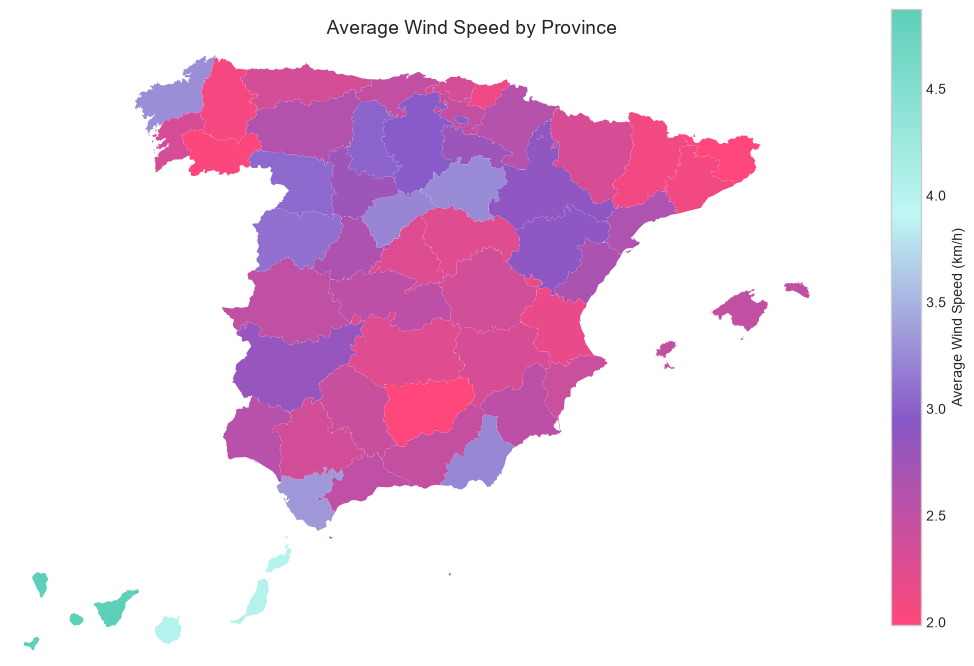

In [5]:
spain = gpd.read_file("https://raw.githubusercontent.com/codeforgermany/click_that_hood/main/public/data/spain-provinces.geojson")
spain = spain.to_crs(epsg=4326)

spain["provincia"] = spain["name"].map(prov_map)

df_agg = df_pd.groupby("provincia")["velocidad_viento_media"].mean().reset_index()
df_agg.columns = ["provincia", "viento_medio"]

map_df = spain.merge(df_agg, on="provincia")

canarias = map_df[map_df["provincia"].isin(["LAS PALMAS", "SANTA CRUZ DE TENERIFE"])]
peninsula = map_df[~map_df["provincia"].isin(["LAS PALMAS", "SANTA CRUZ DE TENERIFE"])]

cmap = LinearSegmentedColormap.from_list("custom", ["#FF477B", "#8858C8", "#C0F7F4", "#5ECFB8"])

fig, ax = plt.subplots(1, 1, figsize=(12, 8))
map_df.plot(
    column="viento_medio",
    ax=ax,
    legend=True,
    cmap=cmap,
    legend_kwds={"label": "Average Wind Speed (km/h)"}
)

ax_inset = fig.add_axes([0.05, 0.05, 0.25, 0.2])
canarias.plot(column="viento_medio", ax=ax_inset, cmap=cmap,
    vmin=map_df["viento_medio"].min(), vmax=map_df["viento_medio"].max())
ax_inset.set_axis_off()

ax.set_title("Average Wind Speed by Province", fontsize=14)
ax.set_xlim(-10, 5)
ax.set_ylim(35, 44)
ax.set_axis_off()
plt.show()

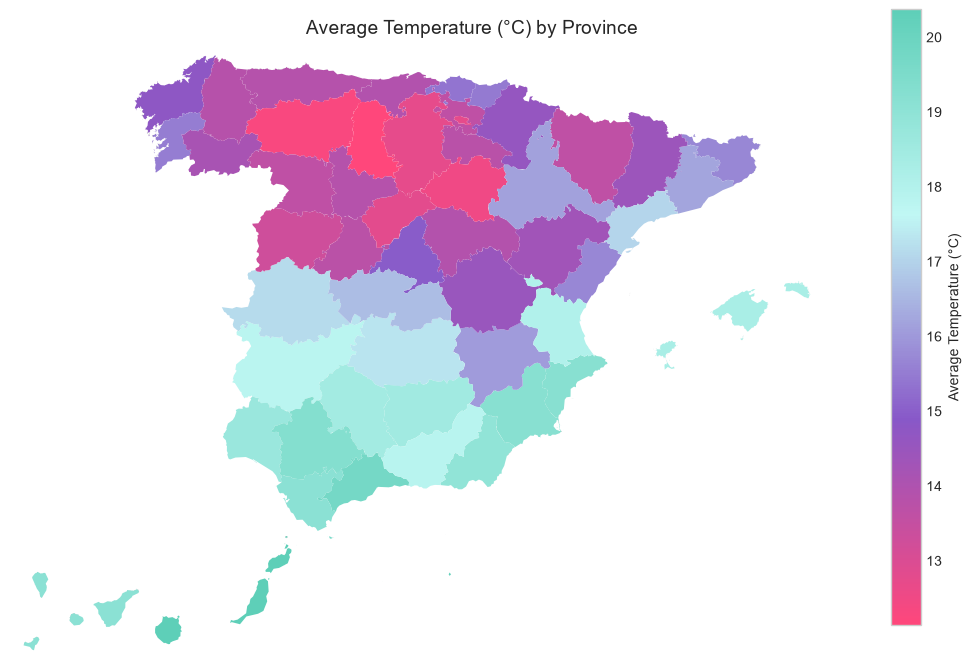

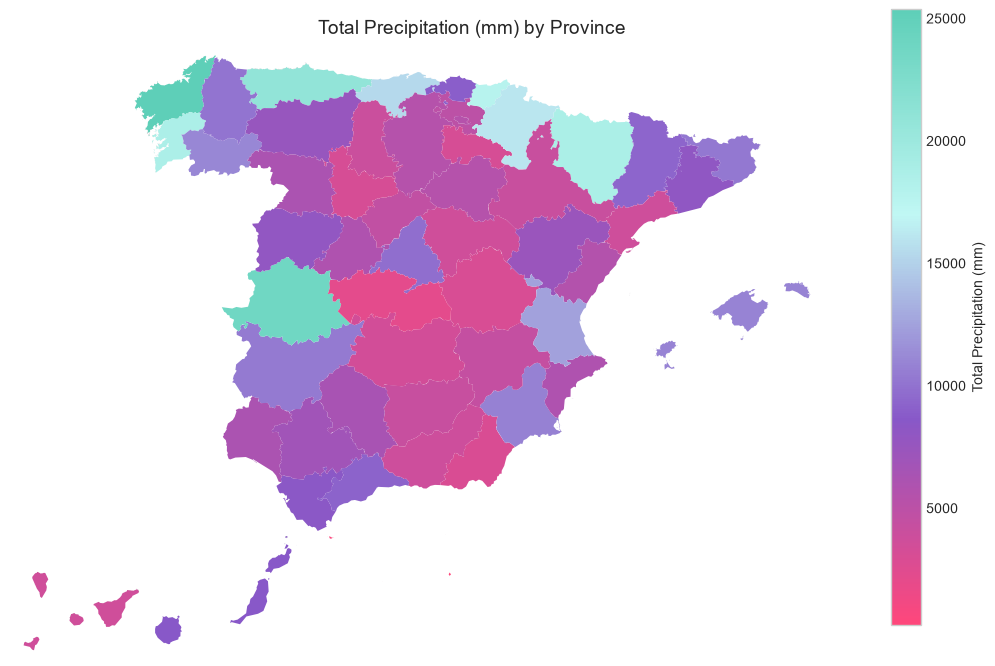

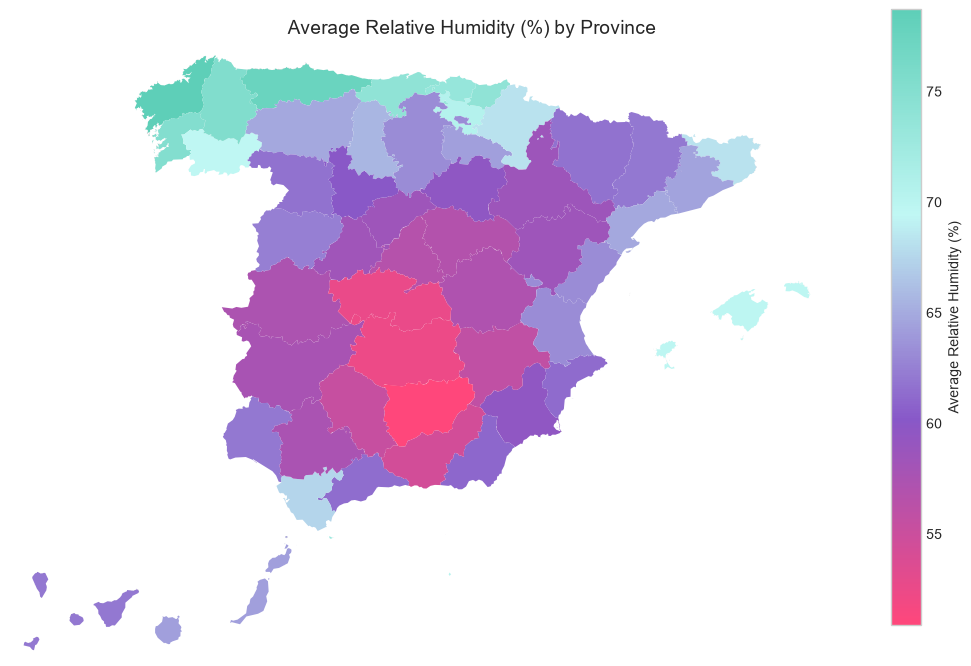

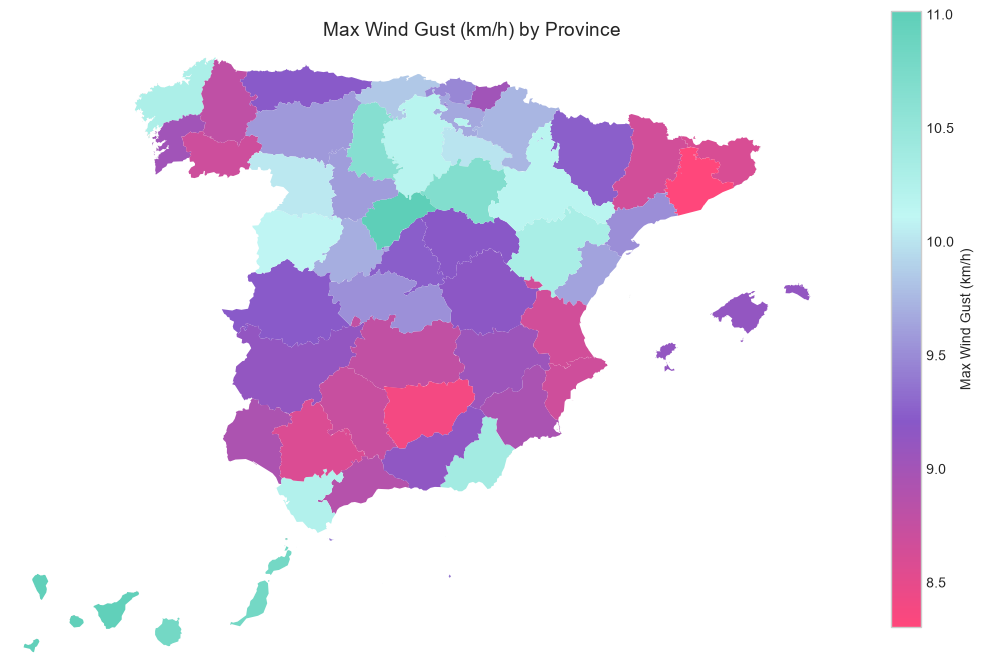

In [6]:
variables = {
    "temperatura_media": "Average Temperature (°C)",
    "precipitacion": "Total Precipitation (mm)",
    "humedad_relativa_media": "Average Relative Humidity (%)",
    "racha_maxima_viento": "Max Wind Gust (km/h)"
}

agg_funcs = {
    "temperatura_media": "mean",
    "precipitacion": "sum",
    "humedad_relativa_media": "mean",
    "racha_maxima_viento": "mean"
}

for var, label in variables.items():
    
    df_agg = df_pd.groupby("provincia")[var].agg(agg_funcs[var]).reset_index()
    df_agg.columns = ["provincia", "valor"]

    map_df = spain.merge(df_agg, on="provincia")

    canarias = map_df[map_df["provincia"].isin(["LAS PALMAS", "SANTA CRUZ DE TENERIFE"])]
    peninsula = map_df[~map_df["provincia"].isin(["LAS PALMAS", "SANTA CRUZ DE TENERIFE"])]

    cmap = LinearSegmentedColormap.from_list("custom", ["#FF477B", "#8858C8", "#C0F7F4", "#5ECFB8"])

    fig, ax = plt.subplots(1, 1, figsize=(12, 8))
    map_df.plot(column="valor", ax=ax, legend=True, cmap=cmap,
        legend_kwds={"label": label})

    ax_inset = fig.add_axes([0.05, 0.05, 0.25, 0.2])
    canarias.plot(column="valor", ax=ax_inset, cmap=cmap,
        vmin=map_df["valor"].min(), vmax=map_df["valor"].max())
    ax_inset.set_axis_off()

    ax.set_title(f"{label} by Province", fontsize=14)
    ax.set_xlim(-10, 5)
    ax.set_ylim(35, 44)
    ax.set_axis_off()
    plt.show()